In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv('CKD.csv')

In [3]:
dataset

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,2.000000,76.459948,c,3.0,0.0,normal,abnormal,notpresent,notpresent,148.112676,...,38.868902,8408.191126,4.705597,no,no,no,yes,yes,no,yes
1,3.000000,76.459948,c,2.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,34.000000,12300.000000,4.705597,no,no,no,yes,poor,no,yes
2,4.000000,76.459948,a,1.0,0.0,normal,normal,notpresent,notpresent,99.000000,...,34.000000,8408.191126,4.705597,no,no,no,yes,poor,no,yes
3,5.000000,76.459948,d,1.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,38.868902,8408.191126,4.705597,no,no,no,yes,poor,yes,yes
4,5.000000,50.000000,c,0.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,36.000000,12400.000000,4.705597,no,no,no,yes,poor,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,51.492308,70.000000,a,0.0,0.0,normal,normal,notpresent,notpresent,219.000000,...,37.000000,9800.000000,4.400000,no,no,no,yes,poor,no,yes
395,51.492308,70.000000,c,0.0,2.0,normal,normal,notpresent,notpresent,220.000000,...,27.000000,8408.191126,4.705597,yes,yes,no,yes,poor,yes,yes
396,51.492308,70.000000,c,3.0,0.0,normal,normal,notpresent,notpresent,110.000000,...,26.000000,9200.000000,3.400000,yes,yes,no,poor,poor,no,yes
397,51.492308,90.000000,a,0.0,0.0,normal,normal,notpresent,notpresent,207.000000,...,38.868902,8408.191126,4.705597,yes,yes,no,yes,poor,yes,yes


In [4]:
dataset=pd.get_dummies(dataset,dtype=int,drop_first=True)

In [5]:
dataset

,age,bp,al,su,bgr,bu,sc,sod,pot,hrmo,...,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_yes,pe_yes,ane_yes,classification_yes
0,2.000000,76.459948,3.0,0.0,148.112676,57.482105,3.077356,137.528754,4.627244,12.518156,...,0,0,0,0,0,0,1,1,0,1
1,3.000000,76.459948,2.0,0.0,148.112676,22.000000,0.700000,137.528754,4.627244,10.700000,...,1,0,0,0,0,0,1,0,0,1
2,4.000000,76.459948,1.0,0.0,99.000000,23.000000,0.600000,138.000000,4.400000,12.000000,...,1,0,0,0,0,0,1,0,0,1
3,5.000000,76.459948,1.0,0.0,148.112676,16.000000,0.700000,138.000000,3.200000,8.100000,...,1,0,0,0,0,0,1,0,1,1
4,5.000000,50.000000,0.0,0.0,148.112676,25.000000,0.600000,137.528754,4.627244,11.800000,...,1,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,51.492308,70.000000,0.0,0.0,219.000000,36.000000,1.300000,139.000000,3.700000,12.500000,...,1,0,0,0,0,0,1,0,0,1
395,51.492308,70.000000,0.0,2.0,220.000000,68.000000,2.800000,137.528754,4.627244,8.700000,...,1,0,0,1,1,0,1,0,1,1
396,51.492308,70.000000,3.0,0.0,110.000000,115.000000,6.000000,134.000000,2.700000,9.100000,...,1,0,0,1,1,0,0,0,0,1
397,51.492308,90.000000,0.0,0.0,207.000000,80.000000,6.800000,142.000000,5.500000,8.500000,...,1,0,0,1,1,0,1,0,1,1


In [9]:
dataset.columns

Index(['age', 'bp', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hrmo', 'pcv',
       'wc', 'rc', 'sg_b', 'sg_c', 'sg_d', 'sg_e', 'rbc_normal', 'pc_normal',
       'pcc_present', 'ba_present', 'htn_yes', 'dm_yes', 'cad_yes',
       'appet_yes', 'pe_yes', 'ane_yes', 'classification_yes'],
      dtype='object')

In [10]:
indep=dataset[['age', 'bp', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hrmo', 'pcv',
       'wc', 'rc', 'sg_b', 'sg_c', 'sg_d', 'sg_e', 'rbc_normal', 'pc_normal',
       'pcc_present', 'ba_present', 'htn_yes', 'dm_yes', 'cad_yes',
       'appet_yes', 'pe_yes', 'ane_yes']]
dep=dataset[['classification_yes']]

In [11]:
dataset['classification_yes'].value_counts()

classification_yes
1    249
0    150
Name: count, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(indep,dep,random_state=0,test_size=1/3)

In [13]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan','minkowski'],
    'p': [1, 2]}
grid = GridSearchCV( KNeighborsClassifier(), param_grid, refit = True, verbose = 3,n_jobs=-1,scoring='f1_weighted') 
   
grid=grid.fit(X_train, y_train) 


Fitting 5 folds for each of 48 candidates, totalling 240 fits


C:\Anaconda3.12.v\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [15]:
print(grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}


In [17]:
y_pred=grid.predict(X_test)

In [18]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

In [22]:
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, y_pred,target_names=["CKD_KNN_NO","CKD_KNN_YES"])

In [23]:
print(cm)

[[51  0]
 [ 4 78]]


In [24]:
print(clf_report)

              precision    recall  f1-score   support

  CKD_KNN_NO       0.93      1.00      0.96        51
 CKD_KNN_YES       1.00      0.95      0.97        82

    accuracy                           0.97       133
   macro avg       0.96      0.98      0.97       133
weighted avg       0.97      0.97      0.97       133



In [25]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,grid.predict_proba(X_test)[:,1])

0.9873266379722621

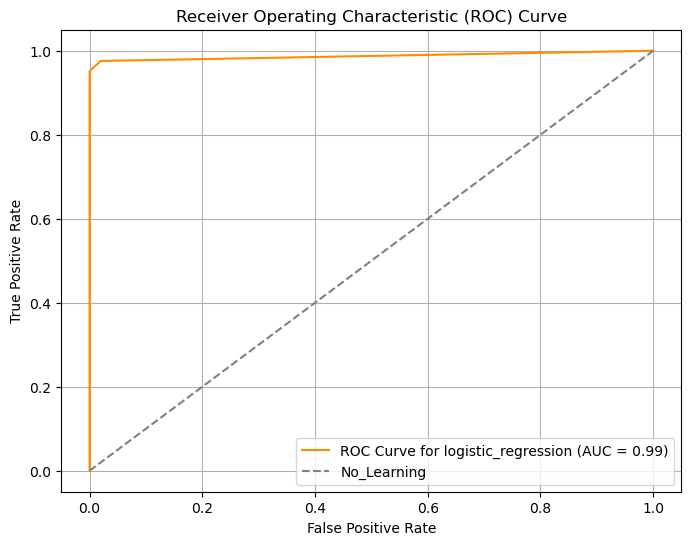

In [26]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_probs = grid.predict_proba(X_test)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Plot the ROC curve
plt.figure(figsize=(8, 6))

# Plot ROC curve
plt.plot(fpr, tpr, label=f'ROC Curve for logistic_regression (AUC = {roc_auc_score(y_test, y_probs):.2f})', color='darkorange')

# Plot diagonal line with label
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='No_Learning')

# Add labels and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [27]:
age_input=int(input('Enter_age:'))
bp_input=int(input('Enter_bp:'))
al_input=int(input('Enter_al:'))
su_input=int(input('Enter_su:'))
bgr_input=int(input('Enter_bgr:'))
bu_input=int(input('Enter_bu:'))
sc_input=int(input('Enter_sc:'))
sod_input=int(input('Enter_sod:'))
pot_input=int(input('Enter_pot:'))
hrmo_input=int(input('Enter_hrmo:'))
pcv_input=int(input('Enter_pcv:'))
wc_input=int(input('Enter_wc:'))
rc_input=int(input('Enter_rc'))
sg_b_input=int(input('Enter_sg_b:'))
sg_c_input=int(input('Enter_sg_c:'))
sg_d_input=int(input('Enter_sg_d:'))
sg_e_input=int(input('Enter_sg_e:'))
rbc_normal_input=int(input('Enter_rbc_normal:'))
pc_normal_input=int(input('Enter_pc_normal:'))
pcc_present_input=int(input('Enter_pcc_present:'))
ba_present_input=int(input('Enter_ba_present_:'))
htn_yes_input=int(input('Enter_htn_yes:'))
dm_yes_input=int(input('Enter_dm_yes:'))
cad_yes_input=int(input('Enter_cad_yes:'))
appet_yes_input=int(input('Enter_appet_yes:'))
pe_yes_input=int(input('Enter_pe_yes:'))
ane_yes_input=int(input('Enter_ane_yes:'))

Enter_age: 31
Enter_bp: 100
Enter_al: 4
Enter_su: 4
Enter_bgr: 140
Enter_bu: 223
Enter_sc: 12
Enter_sod: 150
Enter_pot: 5
Enter_hrmo: 17
Enter_pcv: 52
Enter_wc: 12400
Enter_rc 6
Enter_sg_b: 1
Enter_sg_c: 1
Enter_sg_d: 1
Enter_sg_e: 1
Enter_rbc_normal: 0
Enter_pc_normal: 0
Enter_pcc_present: 0
Enter_ba_present_: 0
Enter_htn_yes: 0
Enter_dm_yes: 0
Enter_cad_yes: 0
Enter_appet_yes: 0
Enter_pe_yes: 0
Enter_ane_yes: 0


In [28]:
CKD_KNN_Prediction=grid.predict([[age_input,bp_input,al_input,su_input,bgr_input,bu_input,
                                             sc_input,sod_input,pot_input,hrmo_input,pcv_input,wc_input,rc_input,sg_b_input,
                                             sg_c_input,sg_d_input,sg_e_input,rbc_normal_input,pc_normal_input,pcc_present_input,ba_present_input,htn_yes_input,
                                             dm_yes_input,cad_yes_input,appet_yes_input,pe_yes_input,ane_yes_input]])
print("CKD_Prediction={}".format(CKD_KNN_Prediction))

CKD_Prediction=[1]
